# Mini Project CNN

## Klasifikasi Citra Daun Padi Menggunakan Convolutional Neural Network (CNN)

**Dataset:** RiceLeafsv3  
**Metode:** Convolutional Neural Network (CNN)  
**Framework:** TensorFlow / Keras

## 1. Load Dataset

Dataset yang digunakan pada penelitian ini adalah **RiceLeafsv3** yang berisi citra daun padi dengan beberapa kelas penyakit.

Dataset dibagi menjadi dua bagian, yaitu:
- **Training dataset** digunakan untuk proses pelatihan model CNN.
- **Validation dataset** digunakan untuk mengevaluasi performa model terhadap data yang belum digunakan saat training.

Seluruh citra diseragamkan menjadi ukuran **128 × 128 piksel** dengan **batch size 32** agar sesuai dengan kebutuhan input model CNN.

In [4]:
# Import library 
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow Version:", tf.__version__)
print("Environment siap digunakan")

TensorFlow Version: 2.21.0
Environment siap digunakan


In [5]:
# Lokasi dataset
train_dir = r"E:\geosoftware - 2026\deep learning - CNN\project\RiceLeafsv3\train"

validation_dir = r"E:\geosoftware - 2026\deep learning - CNN\project\RiceLeafsv3\validation"

print("Path training :", train_dir)
print("Path validation :", validation_dir)

Path training : E:\geosoftware - 2026\deep learning - CNN\project\RiceLeafsv3\train
Path validation : E:\geosoftware - 2026\deep learning - CNN\project\RiceLeafsv3\validation


In [6]:
# Membaca dataset training
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128,128),
    batch_size=32
)

# Membaca dataset validation
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(128,128),
    batch_size=32
)

Found 2167 files belonging to 6 classes.
Found 543 files belonging to 6 classes.


In [7]:
# Menampilkan nama kelas
class_names = train_dataset.class_names

print("Jumlah kelas :", len(class_names))
print("Daftar kelas:")

for i, name in enumerate(class_names):
    print(i, "-", name)

Jumlah kelas : 6
Daftar kelas:
0 - bacterial_leaf_blight
1 - brown_spot
2 - healthy
3 - leaf_blast
4 - leaf_scald
5 - narrow_brown_spot


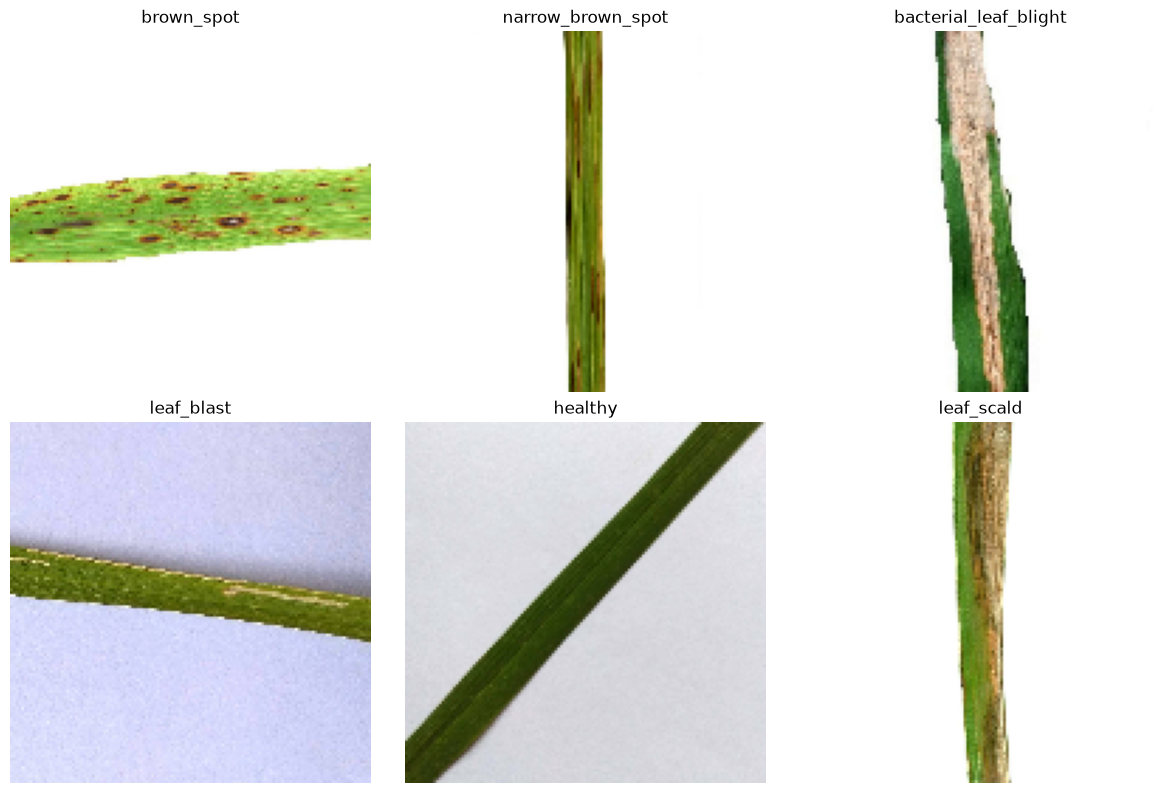

In [8]:
# Menampilkan contoh satu citra dari masing-masing kelas dataset training
plt.figure(figsize=(12,8))

kelas_terpilih = []

for images, labels in train_dataset:
    
    for i in range(len(images)):
        
        nama_kelas = class_names[labels[i]]
        
        if nama_kelas not in kelas_terpilih:
            
            kelas_terpilih.append(nama_kelas)
            
            plt.subplot(2,3,len(kelas_terpilih))
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(nama_kelas)
            plt.axis("off")
        
        if len(kelas_terpilih) == 6:
            break
            
    if len(kelas_terpilih) == 6:
        break

plt.tight_layout()
plt.show()

# 2. Preprocessing Data

Tahap preprocessing dilakukan untuk mempersiapkan citra sebelum masuk ke proses training model CNN.

Tahapan preprocessing meliputi:
- Resize citra menjadi ukuran yang sama.
- Normalisasi nilai piksel.
- Augmentasi sederhana pada data training.

In [9]:
# Normalisasi nilai pixel dari 0-255 menjadi 0-1
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

print("Normalisasi selesai")

Normalisasi selesai


In [11]:
# Augmentasi sederhana pada data training
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

print("Augmentasi siap digunakan")

Augmentasi siap digunakan


# 3. Membangun Model CNN

Model CNN digunakan untuk melakukan klasifikasi citra daun padi menjadi enam kelas penyakit.

Arsitektur model terdiri dari:
- Convolutional Layer (Conv2D)
- Pooling Layer (MaxPooling2D)
- Flatten Layer
- Dense Layer

In [13]:
# Membangun Model CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Membuat arsitektur CNN
model = Sequential([

# Input ukuran citra 128x128 dengan 3 channel warna RGB
Input(shape=(128,128,3)),

# Augmentasi data training
data_augmentation,

# Convolution Layer untuk mengekstraksi fitur citra
Conv2D(
 32,
 (3,3),
 activation="relu"
 ),

# Mengurangi ukuran feature map
MaxPooling2D(2,2),

# Convolution Layer kedua
Conv2D(
 64,
 (3,3),
  activation="relu"
  ),

# Mengurangi dimensi fitur
MaxPooling2D(2,2),

# Mengubah feature map menjadi satu dimensi
Flatten(),

# Fully Connected Layer
Dense(
  128,
  activation="relu"
 ),

# Mengurangi overfitting
Dropout(0.5),

# Output 6 kelas klasifikasi
Dense(
 6,
 activation="softmax"
 )
])

# Melihat struktur model
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,094 (28.20 MB)

 Trainable params: 7,393,094 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

# 4. Training Model

Tahap training dilakukan untuk melatih model CNN menggunakan dataset training dan mengevaluasi performanya menggunakan dataset validation.

Konfigurasi training:
- Optimizer: Adam
- Loss function: Sparse Categorical Crossentropy
- Batch size: 32
- Epoch: 20

In [14]:
# Konfigurasi model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Proses training model
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20
)

Epoch 1/20


c:\Users\dedyl\anaconda3\envs\env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 281ms/step - accuracy: 0.3110 - loss: 1.7810 - val_accuracy: 0.4107 - val_loss: 1.3957
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 346ms/step - accuracy: 0.5224 - loss: 1.2152 - val_accuracy: 0.5672 - val_loss: 1.1570
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 16s 227ms/step - accuracy: 0.6696 - loss: 0.9119 - val_accuracy: 0.7643 - val_loss: 0.6521
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 16s 227ms/step - accuracy: 0.6876 - loss: 0.8536 - val_accuracy: 0.7808 - val_loss: 0.6792
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 16s 225ms/step - accuracy: 0.7402 - loss: 0.7230 - val_accuracy: 0.7532 - val_loss: 0.6651
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 22s 317ms/step - accuracy: 0.7642 - loss: 0.6543 - val_accuracy: 0.7440 - val_loss: 0.6737
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.7766 - loss: 0.6370 - val_accuracy: 0.8066 - val_loss: 0.5498
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 53s 775ms/step - accuracy: 0.8025 - loss: 0.5420 - val_accuracy: 0.8269 -

# 5. Evaluasi Model

Evaluasi dilakukan untuk mengetahui performa model CNN menggunakan data validation.

Evaluasi yang dilakukan meliputi:
- Grafik accuracy training dan validation.
- Grafik loss training dan validation.
- Confusion matrix.
- Classification report.

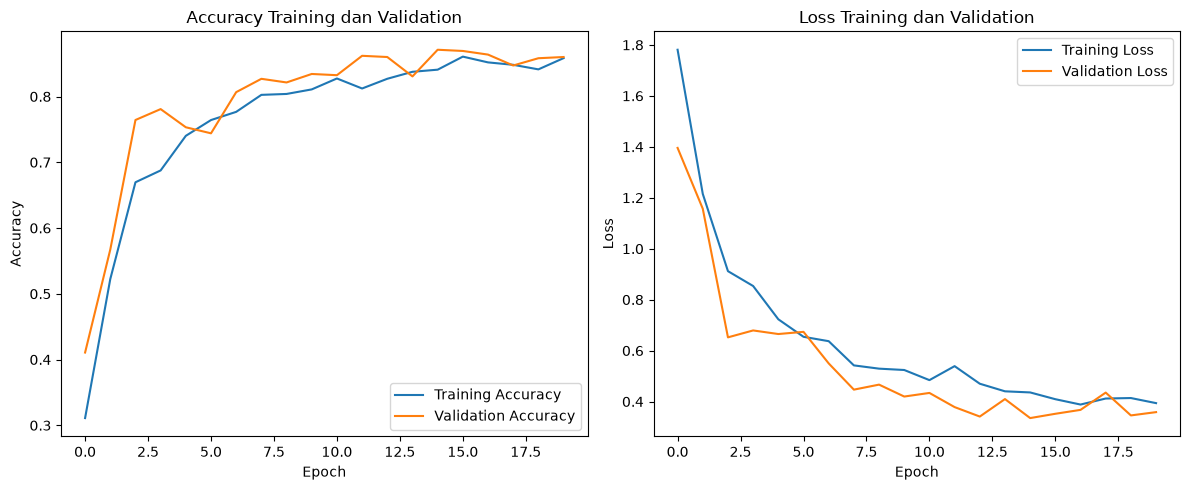

In [15]:
# Menampilkan grafik accuracy dan loss training
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

# Grafik accuracy
plt.subplot(1,2,1)
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy Training dan Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Grafik loss
plt.subplot(1,2,2)
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss Training dan Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

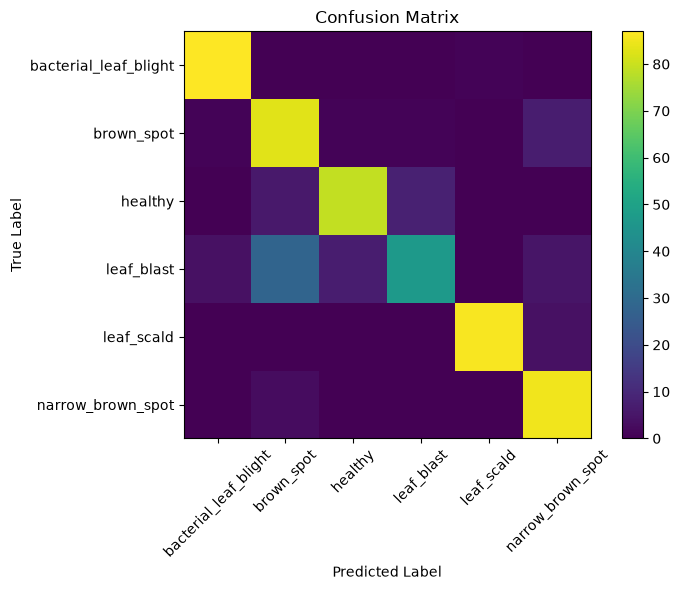

In [16]:
# Evaluasi menggunakan confusion matrix
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in validation_dataset:
    prediction = model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(prediction, axis=1)
    )


cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.tight_layout()
plt.show()

In [17]:
# Evaluasi menggunakan classification report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                       precision    recall  f1-score   support

bacterial_leaf_blight       0.95      0.99      0.97        88
           brown_spot       0.69      0.89      0.78        93
              healthy       0.91      0.85      0.88        93
           leaf_blast       0.84      0.52      0.64        91
           leaf_scald       0.99      0.96      0.97        90
    narrow_brown_spot       0.84      0.97      0.90        88

             accuracy                           0.86       543
            macro avg       0.87      0.86      0.86       543
         weighted avg       0.87      0.86      0.85       543



# 6. Prediksi Citra Baru

Model CNN yang telah dilatih digunakan untuk melakukan prediksi terhadap citra daun padi baru yang belum digunakan dalam proses training.

Hasil prediksi menampilkan:
- Citra yang diprediksi.
- Kelas hasil prediksi.
- Confidence score.

Prediction image list:
E:\geosoftware - 2026\deep learning - CNN\project\RiceLeafsv3\validation\bacterial_leaf_blight\bacterial_val (87).jpg
E:\geosoftware - 2026\deep learning - CNN\project\RiceLeafsv3\validation\brown_spot\brown_val (61).JPG
E:\geosoftware - 2026\deep learning - CNN\project\RiceLeafsv3\validation\healthy\healthy_val (5).jpg
E:\geosoftware - 2026\deep learning - CNN\project\RiceLeafsv3\validation\leaf_blast\leaf_blast_val (61).jpg
E:\geosoftware - 2026\deep learning - CNN\project\RiceLeafsv3\validation\leaf_scald\leaf_scald_val (16).jpg
E:\geosoftware - 2026\deep learning - CNN\project\RiceLeafsv3\validation\narrow_brown_spot\narrow_brown_val (71).jpg
Image : bacterial_val (87).jpg
Actual Class : bacterial_leaf_blight
Predicted Class : bacterial_leaf_blight
Confidence Score : 99.92%
Image : brown_val (61).JPG
Actual Class : brown_spot
Predicted Class : brown_spot
Confidence Score : 93.27%
Image : healthy_val (5).jpg
Actual Class : healthy
Predicted Class : healthy
Con

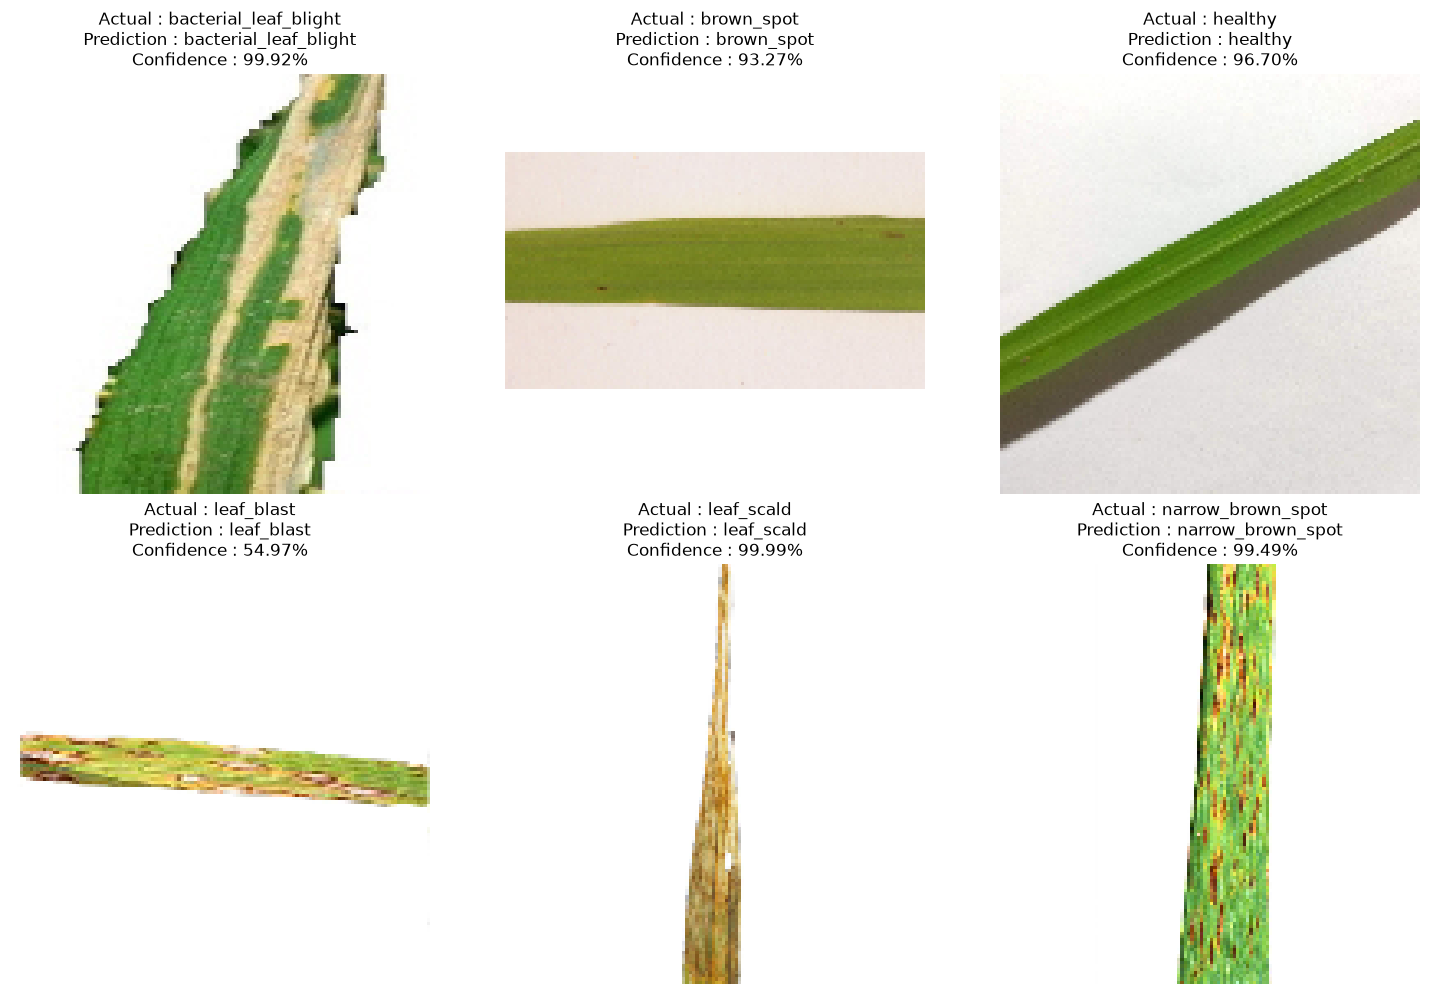

In [44]:
# Prediksi citra baru 
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# Lokasi dataset validasi
validation_path = r"E:\geosoftware - 2026\deep learning - CNN\project\RiceLeafsv3\validation"

# Simpan jalur gambar
image_paths = []

# Pilih satu gambar secara random dari setiap kelas.
for class_name in class_names:
    class_folder = os.path.join(validation_path, class_name)
    image_list = [
        file for file in os.listdir(class_folder)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    selected_image = random.choice(image_list)
    image_paths.append(
        os.path.join(class_folder, selected_image)
    )

print("Prediction image list:")

for image_path in image_paths:
    print(image_path)

# Hasil prediksi
plt.figure(figsize=(15,10))

for i, image_path in enumerate(image_paths):

    # Load citra
    image = tf.keras.utils.load_img(
        image_path,
        target_size=(128,128)
    )

    # Konversi citra ke array
    image_array = tf.keras.utils.img_to_array(image)

    # Normalisasi nilai piksel
    image_array = image_array / 255.0

    # Tambah dimensi batch
    input_image = np.expand_dims(
        image_array,
        axis=0
    )

    # Prediksi
    prediction = model.predict(
        input_image,
        verbose=0
    )

    # kelas prediksi
    predicted_index = np.argmax(prediction)

    predicted_class = class_names[predicted_index]

    # Confidence score
    confidence_score = np.max(prediction)

    print("==============================")
    print("Image :", os.path.basename(image_path))
    print("Actual Class :", os.path.basename(os.path.dirname(image_path)))
    print("Predicted Class :", predicted_class)
    print(f"Confidence Score : {confidence_score*100:.2f}%")

    # Tampil gambar
    plt.subplot(2,3,i+1)

    plt.imshow(image)

    plt.title(
        f"Actual : {os.path.basename(os.path.dirname(image_path))}\n"
        f"Prediction : {predicted_class}\n"
        f"Confidence : {confidence_score*100:.2f}%"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()